In [ ]:
# DSC 640
# Spring 2025
# Project 1 
# Working Document. 
# Created By Matthew Heinen
# 3/15/25

In [4]:
# Packages 
import pandas as pd

#Read Excel
df = pd.read_excel('NDCP2022.xlsx')

# Preview
df.head(5)


,STATE_NAME,STATE_ABBREVIATION,COUNTY_NAME,COUNTY_FIPS_CODE,STUDYYEAR,EMR_16,FEMR_16,MEMR_16,EMR_20to64,FEMR_20to64,...,iFEMP_SERVICE_STATE,iEMP_SALES_STATE,iMEMP_SALES_STATE,iFEMP_SALES_STATE,iEMP_N_STATE,iMEMP_N_STATE,iFEMP_N_STATE,iEMP_P_STATE,iMEMP_P_STATE,iFEMP_P_STATE
0,Alabama,AL,Autauga County,1001,2008,61.5,56.1,67.3,71.4,66.3,...,1,1,1,1,1,1,1,1,1,1
1,Alabama,AL,Autauga County,1001,2009,60.6,54.8,67.0,72.5,66.9,...,1,1,1,1,1,1,1,1,1,1
2,Alabama,AL,Autauga County,1001,2010,60.4,54.9,66.4,72.3,67.4,...,1,1,1,1,1,1,1,1,1,1
3,Alabama,AL,Autauga County,1001,2011,58.7,52.4,65.6,71.0,64.9,...,1,1,1,1,1,1,1,1,1,1
4,Alabama,AL,Autauga County,1001,2012,57.7,52.2,63.8,70.7,65.1,...,1,1,1,1,1,1,1,1,1,1


Female income based insta as

In [80]:
# Filter the dataframe to only include rows where study year is 2022
year_df = df[df['STUDYYEAR'] == 2022]

In [22]:
#select specific columns to keep 
columns_to_keep = ['STATE_ABBREVIATION', 'COUNTY_NAME', 'STUDYYEAR', 'MCINFANT', 
                   'MCTODDLER', 'MCPRESCHOOL', 'FME_2022']
# Create a new DataFrame with only the selected columns
selected_df = year_df[columns_to_keep]

In [24]:
# Preview 
selected_df.head(5)

,STATE_ABBREVIATION,COUNTY_NAME,STUDYYEAR,MCINFANT,MCTODDLER,MCPRESCHOOL,FME_2022
14,AL,Autauga County,2022,145.80,138.72,124.97,30975
29,AL,Baldwin County,2022,133.30,129.14,122.89,30953
44,AL,Barbour County,2022,121.85,116.65,110.40,27128
59,AL,Bibb County,2022,136.43,132.47,128.72,24206
74,AL,Blount County,2022,145.92,150.45,137.95,29955


In [30]:
selected_df['ChildCareCostofFemIncome'] = (((selected_df['MCINFANT']+selected_df['MCTODDLER']+selected_df['MCPRESCHOOL'])/3)*52)/selected_df['FME_2022']

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/3387717203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['ChildCareCostofFemIncome'] = (((selected_df['MCINFANT']+selected_df['MCTODDLER']+selected_df['MCPRESCHOOL'])/3)*52)/selected_df['FME_2022']


In [32]:
selected_df.head(5)


,STATE_ABBREVIATION,COUNTY_NAME,STUDYYEAR,MCINFANT,MCTODDLER,MCPRESCHOOL,FME_2022,ChildCareCostofFemIncome
14,AL,Autauga County,2022,145.80,138.72,124.97,30975,0.229147
29,AL,Baldwin County,2022,133.30,129.14,122.89,30953,0.215780
44,AL,Barbour County,2022,121.85,116.65,110.40,27128,0.222928
59,AL,Bibb County,2022,136.43,132.47,128.72,24206,0.284726
74,AL,Blount County,2022,145.92,150.45,137.95,29955,0.251317


In [36]:
# display 5 lowest cost child care 
low_fem_cost = selected_df.nsmallest(3, 'ChildCareCostofFemIncome')
print(low_fem_cost)

      STATE_ABBREVIATION    COUNTY_NAME  STUDYYEAR  MCINFANT  MCTODDLER  \
40111                 TX  Loving County       2022     155.0      144.0   
35941                 SD    Hyde County       2022     120.0      120.0   
14791                 KS   Trego County       2022      95.6       97.6   

       MCPRESCHOOL  FME_2022  ChildCareCostofFemIncome  
40111        140.0     72275                  0.105283  
35941        114.0     50938                  0.120460  
14791         97.6     35469                  0.142111  


Lowest cost of Childcare Loving County TX (West of Odessa)


In [39]:
# display 5 highest cost child care 
high_fem_cost = selected_df.nlargest(3, 'ChildCareCostofFemIncome')
# Display
print(high_fem_cost)

      STATE_ABBREVIATION        COUNTY_NAME  STUDYYEAR  MCINFANT  MCTODDLER  \
44827                 WA   Wahkiakum County       2022    357.31     248.93   
44287                 VA  Williamsburg City       2022    213.25     137.51   
4276                  CO     Mineral County       2022    176.45     329.10   

       MCPRESCHOOL  FME_2022  ChildCareCostofFemIncome  
44827       248.93     14537                  1.019670  
44287       158.89      9940                  0.888726  
4276        313.50     18142                  0.782541  


/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/328642691.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  big_number = high_fem_cost[(high_fem_cost['STATE_ABBREVIATION'] == 'VA') & (df['COUNTY_NAME'] == 'Williamsburg City')]['ChildCareCostofFemIncome'].values[0]


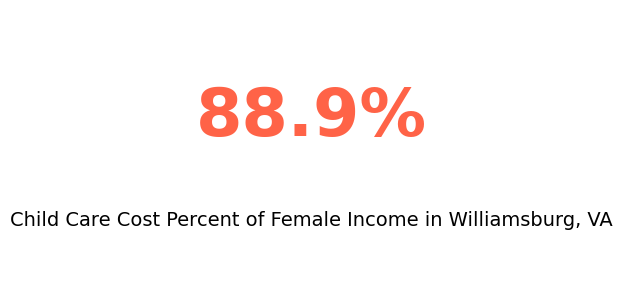

In [303]:
#Make Big number graph to show child care cost williamsburg

# big number
big_number = high_fem_cost[(high_fem_cost['STATE_ABBREVIATION'] == 'VA') & (df['COUNTY_NAME'] == 'Williamsburg City')]['ChildCareCostofFemIncome'].values[0]

fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor('white')
ax.axis('off')  # Hide axes

# Display the number
ax.text(0.5, 0.6, f'{big_number*100:.1f}%', fontsize=48, fontweight='bold', color = 'tomato', ha='center', va='center')
ax.text(0.5, 0.2, 'Child Care Cost Percent of Female Income in Williamsburg, VA', fontsize=14, ha='center')

plt.tight_layout()
plt.show()

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/615337662.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  big_number = low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['ChildCareCostofFemIncome'].values[0]


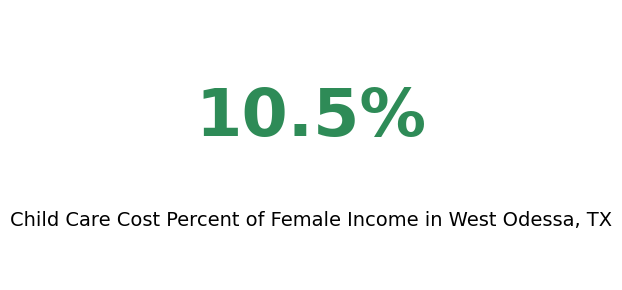

In [307]:
#Make Big number graph to show child care cost odessa, TX

# big number
big_number = low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['ChildCareCostofFemIncome'].values[0]

fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor('white')
ax.axis('off')  # Hide axes

# Display the number
ax.text(0.5, 0.6, f'{big_number*100:.1f}%', fontsize=48, fontweight='bold', color = 'seagreen', ha='center', va='center')
ax.text(0.5, 0.2, 'Child Care Cost Percent of Female Income in West Odessa, TX', fontsize=14, ha='center')

plt.tight_layout()
plt.show()

Williamsburg City - between norfolk and Richmond highest cost

In [48]:
# Select only Williamsburgh count and Loving County 
# Define the list of counties and states to filter by
counties = ['Williamsburg City', 'Loving County']
states = ['VA', 'TX']

# Filter the DataFrame
high_low_fem = selected_df[selected_df['COUNTY_NAME'].isin(counties) & selected_df['STATE_ABBREVIATION'].isin(states)]
print(high_low_fem)

      STATE_ABBREVIATION        COUNTY_NAME  STUDYYEAR  MCINFANT  MCTODDLER  \
40111                 TX      Loving County       2022    155.00     144.00   
44287                 VA  Williamsburg City       2022    213.25     137.51   

       MCPRESCHOOL  FME_2022  ChildCareCostofFemIncome  
40111       140.00     72275                  0.105283  
44287       158.89      9940                  0.888726  


/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/3084174400.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_low_fem['County_State'] = high_low_fem['COUNTY_NAME'] + ', ' + high_low_fem['STATE_ABBREVIATION']
/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/3084174400.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_low_fem['Avg_Weekly_Cost'] = (high_low_fem['MCTODDLER'] + high_low_fem['MCPRESCHOOL'] + high_low_fem['MCINFANT']) / 3
/var/folders/xv/q0156cqs67s40w

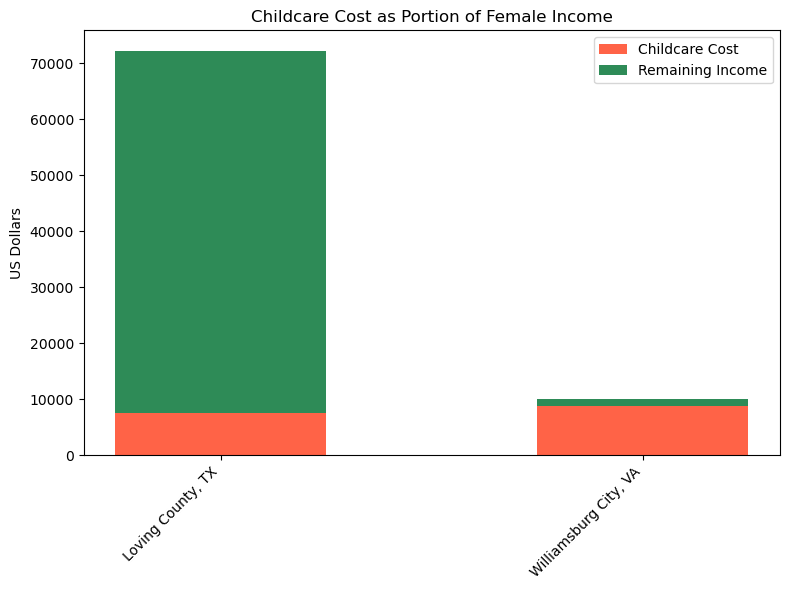

In [319]:
import matplotlib.pyplot as plt

# Combine county and state for x-axis labels
high_low_fem['County_State'] = high_low_fem['COUNTY_NAME'] + ', ' + high_low_fem['STATE_ABBREVIATION']

# Calculate average weekly cost and annual childcare cost (Center based)
high_low_fem['Avg_Weekly_Cost'] = (high_low_fem['MCTODDLER'] + high_low_fem['MCPRESCHOOL'] + high_low_fem['MCINFANT']) / 3
high_low_fem['Annual_Childcare_Cost'] = high_low_fem['Avg_Weekly_Cost'] * 52

# Calculate remaining income after childcare
high_low_fem['Remaining_Income'] = high_low_fem['FME_2022'] - high_low_fem['Annual_Childcare_Cost']

# Plot stacked bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(high_low_fem['County_State'], high_low_fem['Annual_Childcare_Cost'], label='Childcare Cost', color='tomato', width = 0.5)
plt.bar(high_low_fem['County_State'], high_low_fem['Remaining_Income'], 
        bottom=high_low_fem['Annual_Childcare_Cost'], label='Remaining Income', color='seagreen', width = 0.5)

plt.title('Childcare Cost as Portion of Female Income')
plt.ylabel('US Dollars')
plt.xticks(rotation=45, ha='right')
plt.legend()
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/1104386210.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_low_fem['County_State'] = high_low_fem['COUNTY_NAME'] + ', ' + high_low_fem['STATE_ABBREVIATION']
/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/1104386210.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_low_fem['Avg_Weekly_Cost'] = (high_low_fem['MCTODDLER'] + high_low_fem['MCPRESCHOOL'] + high_low_fem['MCINFANT']) / 3
/var/folders/xv/q0156cqs67s40w

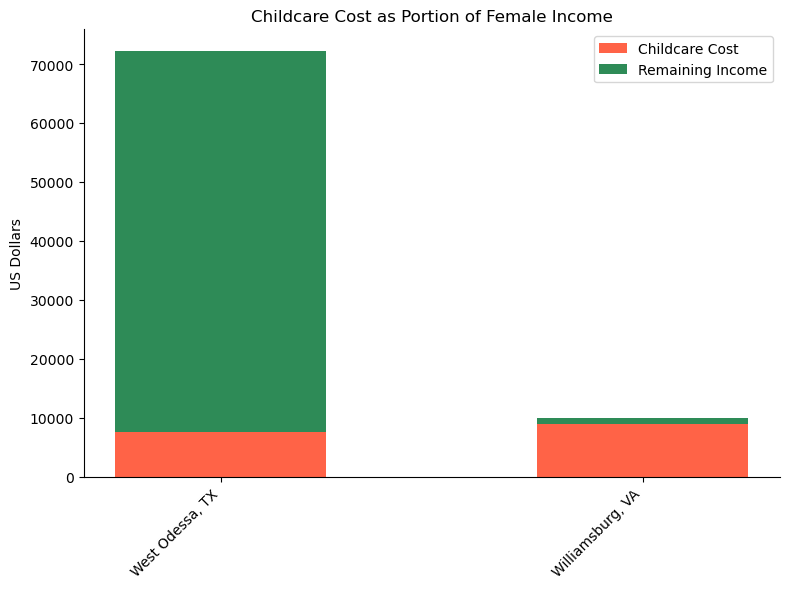

In [329]:
import matplotlib.pyplot as plt

# Combine county and state for x-axis labels
high_low_fem['County_State'] = high_low_fem['COUNTY_NAME'] + ', ' + high_low_fem['STATE_ABBREVIATION']

# Calculate average weekly cost and annual childcare cost (Center based)
high_low_fem['Avg_Weekly_Cost'] = (high_low_fem['MCTODDLER'] + high_low_fem['MCPRESCHOOL'] + high_low_fem['MCINFANT']) / 3
high_low_fem['Annual_Childcare_Cost'] = high_low_fem['Avg_Weekly_Cost'] * 52

# Calculate remaining income after childcare
high_low_fem['Remaining_Income'] = high_low_fem['FME_2022'] - high_low_fem['Annual_Childcare_Cost']

# Manually relabel the County_State column
# Renamed for readability 
high_low_fem.iloc[0, high_low_fem.columns.get_loc('County_State')] = 'West Odessa, TX'
high_low_fem.iloc[1, high_low_fem.columns.get_loc('County_State')] = 'Williamsburg, VA'

# Create plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot stacked bar chart
ax.bar(high_low_fem['County_State'], high_low_fem['Annual_Childcare_Cost'], label='Childcare Cost', color='tomato', width=0.5)
ax.bar(high_low_fem['County_State'], high_low_fem['Remaining_Income'], 
       bottom=high_low_fem['Annual_Childcare_Cost'], label='Remaining Income', color='seagreen', width=0.5)

# Labels and formatting
ax.set_title('Childcare Cost as Portion of Female Income')
ax.set_ylabel('US Dollars')
ax.set_xticks(range(len(high_low_fem)))
ax.set_xticklabels(high_low_fem['County_State'], rotation=45, ha='right')
ax.legend()

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [339]:
low_fem_cost

,STATE_ABBREVIATION,COUNTY_NAME,STUDYYEAR,MCINFANT,MCTODDLER,MCPRESCHOOL,FME_2022,ChildCareCostofFemIncome
40111,TX,Loving County,2022,155.0,144.0,140.0,72275,0.105283
35941,SD,Hyde County,2022,120.0,120.0,114.0,50938,0.120460
14791,KS,Trego County,2022,95.6,97.6,97.6,35469,0.142111


/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/3182799869.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  texas = (low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['FME_2022'].values[0])*(1-low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['ChildCareCostofFemIncome'].values[0])
/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/3182799869.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  texas = (low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['FME_2022'].values[0])*(1-low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['ChildCareCostofFemIncome'].values[0])
/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_26887/3182799869.py:8: UserWarning: Boolean Series key will be reindexed 

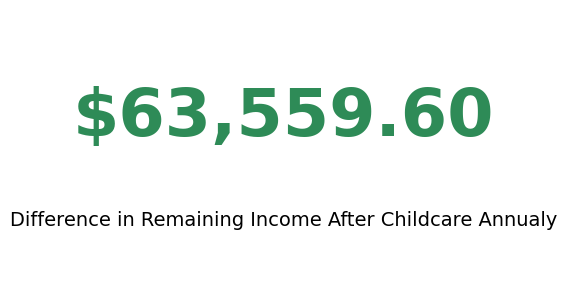

In [345]:
# Make Big Number to show income savings dollars 

#Make Big number graph to show child care cost odessa, TX

# big number
texas = (low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['FME_2022'].values[0])*(1-low_fem_cost[(low_fem_cost['STATE_ABBREVIATION'] == 'TX') & (df['COUNTY_NAME'] == 'Loving County')]['ChildCareCostofFemIncome'].values[0])

virgina = (high_fem_cost[(high_fem_cost['STATE_ABBREVIATION'] == 'VA') & (df['COUNTY_NAME'] == 'Williamsburg City')]['FME_2022'].values[0])*(1-high_fem_cost[(high_fem_cost['STATE_ABBREVIATION'] == 'VA') & (df['COUNTY_NAME'] == 'Williamsburg City')]['ChildCareCostofFemIncome'].values[0])

big_number = texas - virgina

fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor('white')
ax.axis('off')  # Hide axes

# Display the number as dollars
ax.text(0.5, 0.6, f'${big_number:,.2f}', fontsize=48, fontweight='bold', color='seagreen', ha='center', va='center')
ax.text(0.5, 0.2, 'Difference in Remaining Income After Childcare Annualy', fontsize=14, ha='center')

plt.tight_layout()
plt.show()

# Listacle 


In [216]:
#select specific columns to keep 
columns_to_keep = ['STATE_ABBREVIATION', 'COUNTY_NAME', 'STUDYYEAR', 'MFCCINFANT', 
                   'MFCCTODDLER', 'MFCCPRESCHOOL', 'MFI_2022_STATE']
# Create a new DataFrame with only the selected columns
listacle_df = year_df[columns_to_keep]

In [218]:
# Preview DF 
listacle_df

,STATE_ABBREVIATION,COUNTY_NAME,STUDYYEAR,MFCCINFANT,MFCCTODDLER,MFCCPRESCHOOL,MFI_2022_STATE
14,AL,Autauga County,2022,135.73,129.69,129.69,77668
29,AL,Baldwin County,2022,129.48,129.48,129.48,77668
44,AL,Barbour County,2022,104.87,105.72,105.72,77668
59,AL,Bibb County,2022,103.58,103.58,103.58,77668
74,AL,Blount County,2022,145.57,141.82,129.32,77668
...,...,...,...,...,...,...,...
48247,PR,Vega Baja County,2022,NaN,NaN,NaN,29544
48262,PR,Vieques County,2022,NaN,NaN,NaN,29544
48277,PR,Villalba County,2022,NaN,NaN,NaN,29544
48292,PR,Yabucoa County,2022,NaN,NaN,NaN,29544


In [220]:
# Drop county name column 
listacle_df = listacle_df.drop('COUNTY_NAME', axis=1)

# FInd median values grouped by state 
median_by_state = listacle_df.groupby('STATE_ABBREVIATION').median()

In [222]:
# Calculate average weekly cost and annual childcare cost (Family Based)
median_by_state['Avg_Weekly_Cost'] = (median_by_state['MFCCTODDLER'] + median_by_state['MFCCPRESCHOOL'] + median_by_state['MFCCINFANT']) / 3
median_by_state['Annual_Childcare_Cost'] = median_by_state['Avg_Weekly_Cost'] * 52

In [224]:
# Preview 
median_by_state.head(5) 


,STUDYYEAR,MFCCINFANT,MFCCTODDLER,MFCCPRESCHOOL,MFI_2022_STATE,Avg_Weekly_Cost,Annual_Childcare_Cost
STATE_ABBREVIATION,,,,,,,
AK,2022.0,251.470,235.080,224.620,105329.0,237.056667,12326.946667
AL,2022.0,129.320,129.320,128.410,77668.0,129.016667,6708.866667
AR,2022.0,NaN,NaN,NaN,70708.0,NaN,NaN
AZ,2022.0,175.000,175.000,175.000,88679.0,175.000000,9100.000000
CA,2022.0,246.115,219.395,206.945,104823.0,224.151667,11655.886667


In [226]:
# Calculate child care cost of income 
median_by_state['ChildCareCostofIncome'] = median_by_state['Annual_Childcare_Cost'] / median_by_state['MFI_2022_STATE']
median_by_state['InfantCostofIncome'] = (median_by_state['MFCCINFANT']*52)/median_by_state['MFI_2022_STATE']
median_by_state['toddlerCostofIncome'] = (median_by_state['MFCCTODDLER']*52)/median_by_state['MFI_2022_STATE']
median_by_state['PreschoolCostofIncome'] = (median_by_state['MFCCPRESCHOOL']*52)/median_by_state['MFI_2022_STATE']

In [228]:
# display 5 highest cost child care 
high_cost = median_by_state.nlargest(3, 'ChildCareCostofIncome')
# Display
print(high_cost)

                    STUDYYEAR  MFCCINFANT  MFCCTODDLER  MFCCPRESCHOOL  \
STATE_ABBREVIATION                                                      
DC                     2022.0      400.00       393.25         368.25   
RI                     2022.0      259.60       254.20         212.05   
AK                     2022.0      251.47       235.08         224.62   

                    MFI_2022_STATE  Avg_Weekly_Cost  Annual_Childcare_Cost  \
STATE_ABBREVIATION                                                           
DC                        146477.0       387.166667           20132.666667   
RI                        105989.0       241.950000           12581.400000   
AK                        105329.0       237.056667           12326.946667   

                    ChildCareCostofIncome  InfantCostofIncome  \
STATE_ABBREVIATION                                              
DC                               0.137446            0.142002   
RI                               0.118705       

In [230]:
# Display 3 Lowest Cost Child Care
low_cost = median_by_state.nsmallest(3, 'ChildCareCostofIncome')
# Display
print(low_cost)

                    STUDYYEAR  MFCCINFANT  MFCCTODDLER  MFCCPRESCHOOL  \
STATE_ABBREVIATION                                                      
KS                     2022.0        98.4        83.33          83.33   
SD                     2022.0       100.0       100.00         100.00   
GA                     2022.0       103.0        97.00          97.00   

                    MFI_2022_STATE  Avg_Weekly_Cost  Annual_Childcare_Cost  \
STATE_ABBREVIATION                                                           
KS                         89712.0        88.353333            4594.373333   
SD                         89573.0       100.000000            5200.000000   
GA                         86642.0        99.000000            5148.000000   

                    ChildCareCostofIncome  InfantCostofIncome  \
STATE_ABBREVIATION                                              
KS                               0.051212            0.057036   
SD                               0.058053       

In [232]:
# Reset index's 
low_cost = low_cost.reset_index()

high_cost = high_cost.reset_index()

In [234]:
high_cost

,STATE_ABBREVIATION,STUDYYEAR,MFCCINFANT,MFCCTODDLER,MFCCPRESCHOOL,MFI_2022_STATE,Avg_Weekly_Cost,Annual_Childcare_Cost,ChildCareCostofIncome,InfantCostofIncome,toddlerCostofIncome,PreschoolCostofIncome
0,DC,2022.0,400.00,393.25,368.25,146477.0,387.166667,20132.666667,0.137446,0.142002,0.139606,0.130730
1,RI,2022.0,259.60,254.20,212.05,105989.0,241.950000,12581.400000,0.118705,0.127364,0.124715,0.104035
2,AK,2022.0,251.47,235.08,224.62,105329.0,237.056667,12326.946667,0.117033,0.124149,0.116057,0.110893


In [236]:
average_values = median_by_state.mean(numeric_only=True)
print(average_values)

STUDYYEAR                 2022.000000
MFCCINFANT                 168.041023
MFCCTODDLER                159.029886
MFCCPRESCHOOL              154.770227
MFI_2022_STATE           92139.653846
Avg_Weekly_Cost            160.613712
Annual_Childcare_Cost     8351.913030
ChildCareCostofIncome        0.086700
InfantCostofIncome           0.090641
toddlerCostofIncome          0.085802
PreschoolCostofIncome        0.083656
dtype: float64


In [238]:
# Assign to df
national_avg_row = average_values.to_frame().T

# Add 'STATE_ABBREVIATION' value to label this row as index 
national_avg_row['STATE_ABBREVIATION'] = 'National Average'

In [240]:
national_avg_row

,STUDYYEAR,MFCCINFANT,MFCCTODDLER,MFCCPRESCHOOL,MFI_2022_STATE,Avg_Weekly_Cost,Annual_Childcare_Cost,ChildCareCostofIncome,InfantCostofIncome,toddlerCostofIncome,PreschoolCostofIncome,STATE_ABBREVIATION
0,2022.0,168.041023,159.029886,154.770227,92139.653846,160.613712,8351.91303,0.0867,0.090641,0.085802,0.083656,National Average


In [242]:
# Step 4: Reorder columns to match original DataFrame
national_avg_row = national_avg_row[low_cost.columns]

#  Append to low cost DataFrame
low_cost = pd.concat([low_cost, national_avg_row])


In [244]:
#  Append to high cost DataFrame
high_cost = pd.concat([high_cost, national_avg_row])

In [246]:
high_cost

,STATE_ABBREVIATION,STUDYYEAR,MFCCINFANT,MFCCTODDLER,MFCCPRESCHOOL,MFI_2022_STATE,Avg_Weekly_Cost,Annual_Childcare_Cost,ChildCareCostofIncome,InfantCostofIncome,toddlerCostofIncome,PreschoolCostofIncome
0,DC,2022.0,400.000000,393.250000,368.250000,146477.000000,387.166667,20132.666667,0.137446,0.142002,0.139606,0.130730
1,RI,2022.0,259.600000,254.200000,212.050000,105989.000000,241.950000,12581.400000,0.118705,0.127364,0.124715,0.104035
2,AK,2022.0,251.470000,235.080000,224.620000,105329.000000,237.056667,12326.946667,0.117033,0.124149,0.116057,0.110893
0,National Average,2022.0,168.041023,159.029886,154.770227,92139.653846,160.613712,8351.913030,0.086700,0.090641,0.085802,0.083656


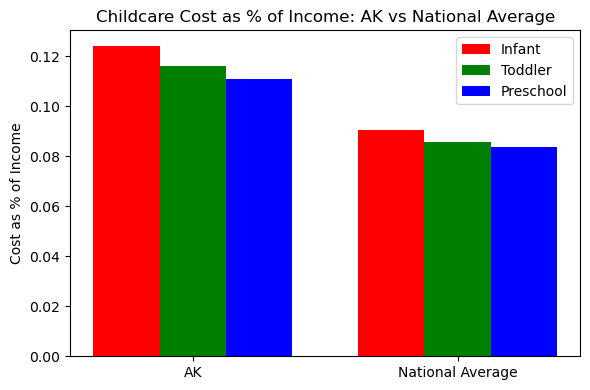

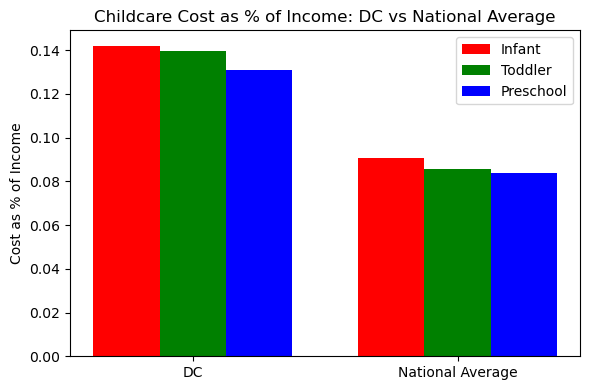

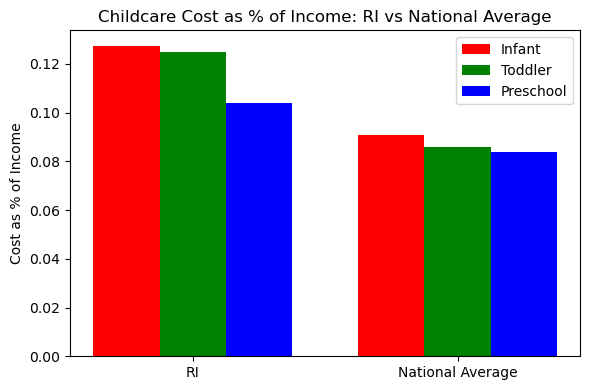

In [250]:
# Build 3 Bar charts for high states

import pandas as pd
import matplotlib.pyplot as plt


# States to graph individually
states = ['AK', 'DC', 'RI']

# Loop through each state and plot side-by-side with National Average
for state in states:
    subset = high_cost[high_cost['STATE_ABBREVIATION'].isin([state, 'National Average'])]
    
    # Bar positions
    x = range(len(subset))
    
    # Plot
    plt.figure(figsize=(6, 4))
    plt.bar(x, subset['InfantCostofIncome'], width=0.25, label='Infant', color='red')
    plt.bar([i + 0.25 for i in x], subset['toddlerCostofIncome'], width=0.25, label='Toddler', color='green')
    plt.bar([i + 0.50 for i in x], subset['PreschoolCostofIncome'], width=0.25, label='Preschool', color='blue')
    
    # Labels and style
    plt.xticks([i + 0.25 for i in x], subset['STATE_ABBREVIATION'])
    plt.ylabel('Cost as % of Income')
    plt.title(f'Childcare Cost as % of Income: {state} vs National Average')
    plt.legend()
    plt.tight_layout()
    plt.show()


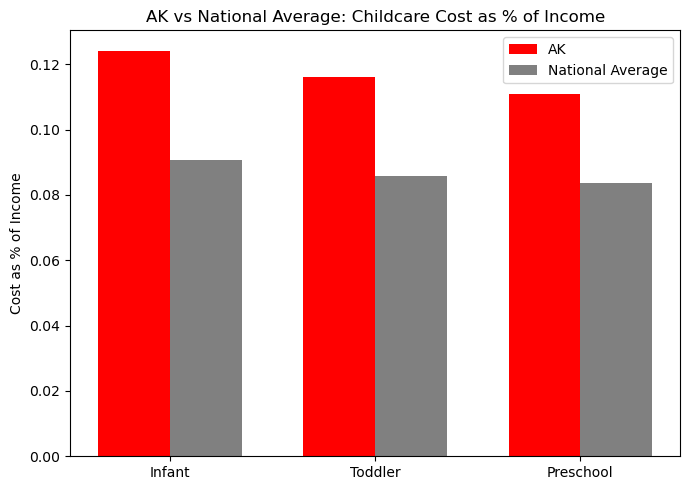

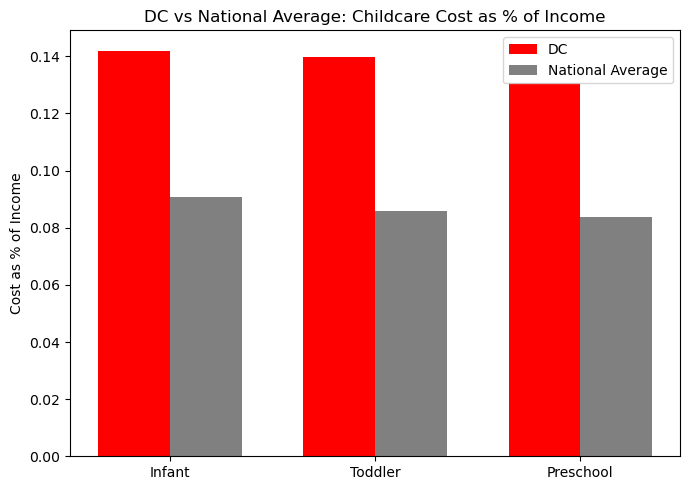

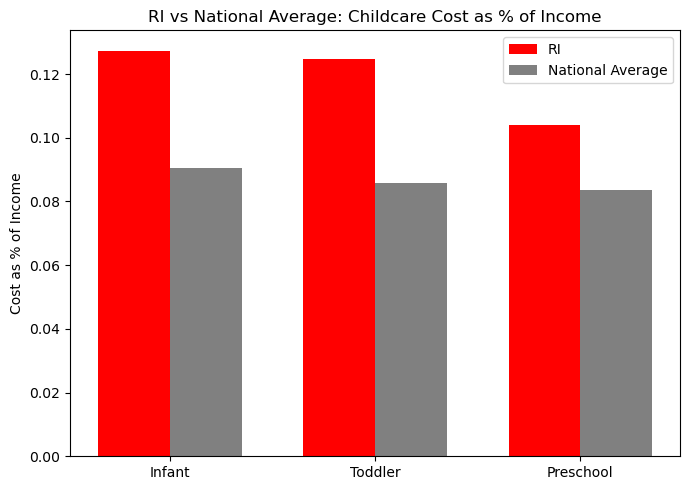

In [256]:
# Now re make as individual pairs 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# States you want to compare with the national average
states = ['AK', 'DC', 'RI']
categories = ['InfantCostofIncome', 'toddlerCostofIncome', 'PreschoolCostofIncome']

for state in states:
    state_vals = high_cost[high_cost['STATE_ABBREVIATION'] == state][categories].values.flatten()
    national_vals = high_cost[high_cost['STATE_ABBREVIATION'] == 'National Average'][categories].values.flatten()
    
    x = np.arange(len(categories))  # [0, 1, 2]
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    
    ax.bar(x - width/2, state_vals, width, label=state, color='red')
    ax.bar(x + width/2, national_vals, width, label='National Average', color='gray')

    ax.set_ylabel('Cost as % of Income')
    ax.set_title(f'{state} vs National Average: Childcare Cost as % of Income')
    ax.set_xticks(x)
    ax.set_xticklabels(['Infant', 'Toddler', 'Preschool'])
    ax.legend()
    plt.tight_layout()
    plt.show()


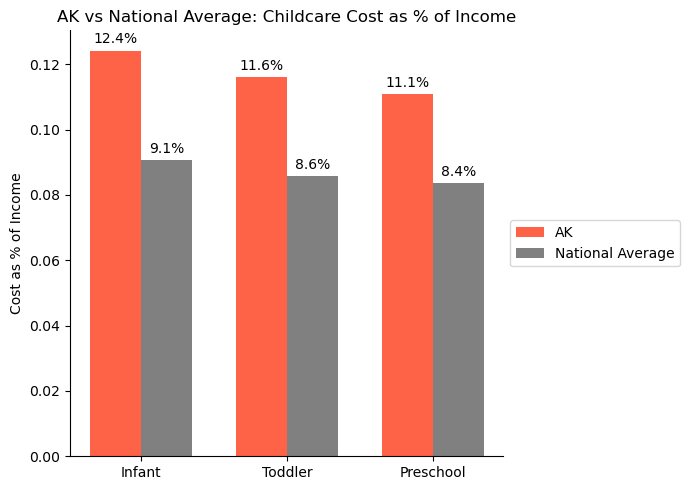

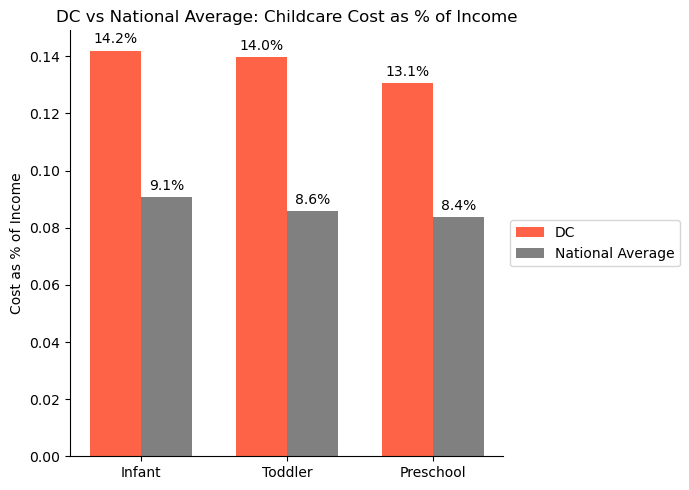

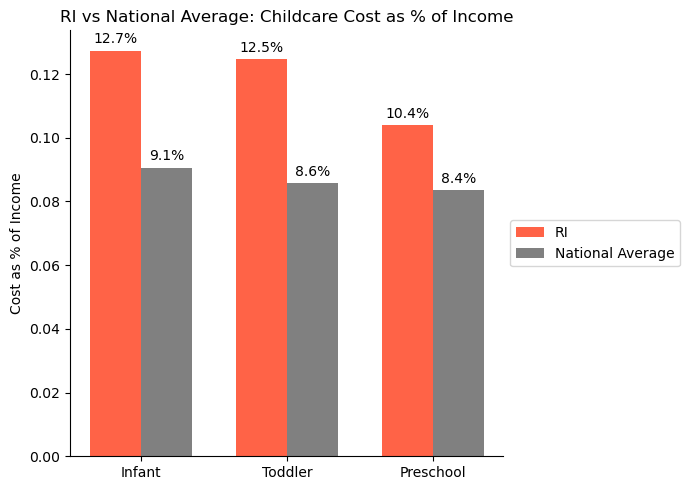

In [283]:
# Add percent labels to graphs above
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# States you want to compare with the national average
states = ['AK', 'DC', 'RI']
categories = ['InfantCostofIncome', 'toddlerCostofIncome', 'PreschoolCostofIncome']

for state in states:
    state_vals = high_cost[high_cost['STATE_ABBREVIATION'] == state][categories].values.flatten()
    national_vals = high_cost[high_cost['STATE_ABBREVIATION'] == 'National Average'][categories].values.flatten()
    
    x = np.arange(len(categories))  # [0, 1, 2]
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    
    bars1 = ax.bar(x - width/2, state_vals, width, label=state, color='tomato')
    bars2 = ax.bar(x + width/2, national_vals, width, label='National Average', color='gray')

    # Add % labels on each bar
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    ax.set_ylabel('Cost as % of Income')
    ax.set_title(f'{state} vs National Average: Childcare Cost as % of Income')
    ax.set_xticks(x)
    ax.set_xticklabels(['Infant', 'Toddler', 'Preschool'])
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Move legend outside the plot
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()


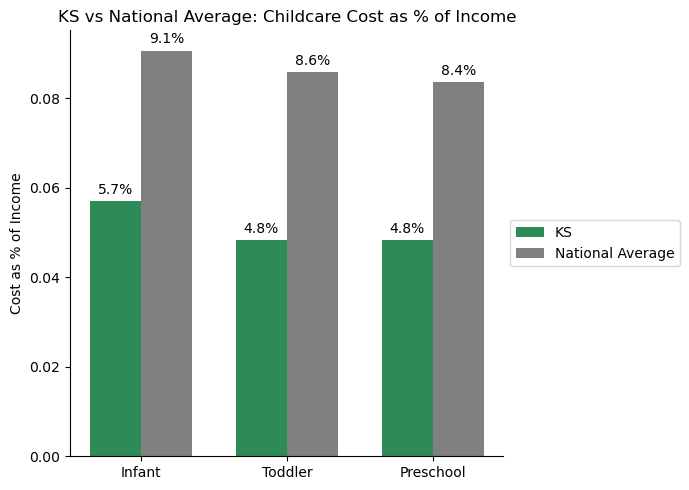

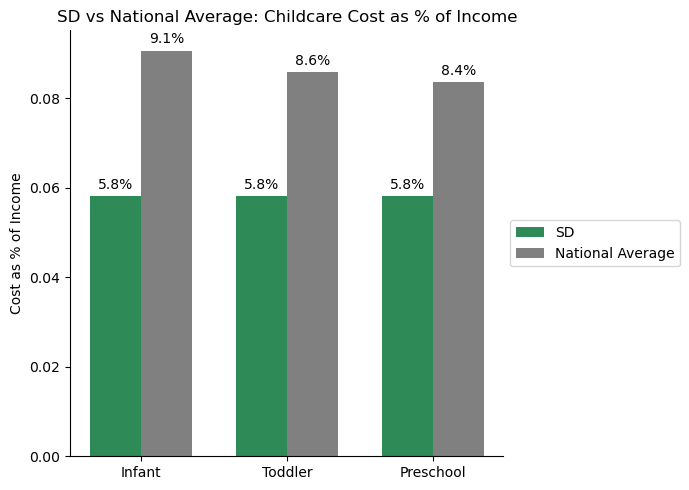

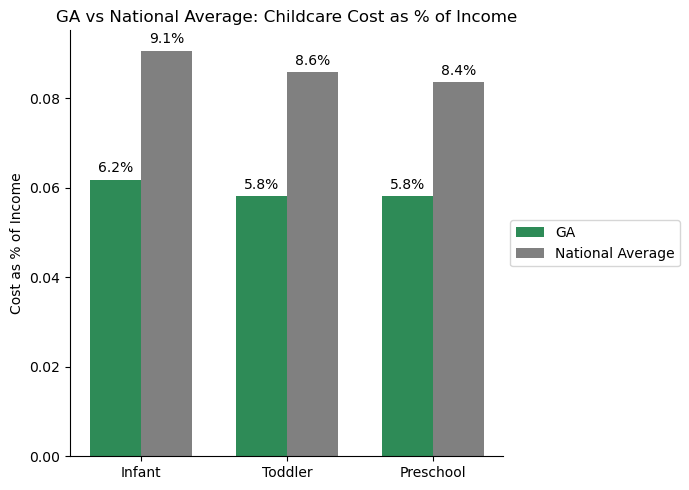

In [285]:
# Repeat for low cost states
# Try to add percent labels
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# States you want to compare with the national average
states = ['KS', 'SD', 'GA']
categories = ['InfantCostofIncome', 'toddlerCostofIncome', 'PreschoolCostofIncome']

for state in states:
    state_vals = low_cost[low_cost['STATE_ABBREVIATION'] == state][categories].values.flatten()
    national_vals = low_cost[low_cost['STATE_ABBREVIATION'] == 'National Average'][categories].values.flatten()
    
    x = np.arange(len(categories))  # [0, 1, 2]
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    
    bars1 = ax.bar(x - width/2, state_vals, width, label=state, color='seagreen')
    bars2 = ax.bar(x + width/2, national_vals, width, label='National Average', color='gray')

    # Add % labels on each bar
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    ax.set_ylabel('Cost as % of Income')
    ax.set_title(f'{state} vs National Average: Childcare Cost as % of Income')
    ax.set_xticks(x)
    ax.set_xticklabels(['Infant', 'Toddler', 'Preschool'])
     # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Move legend outside the plot
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()


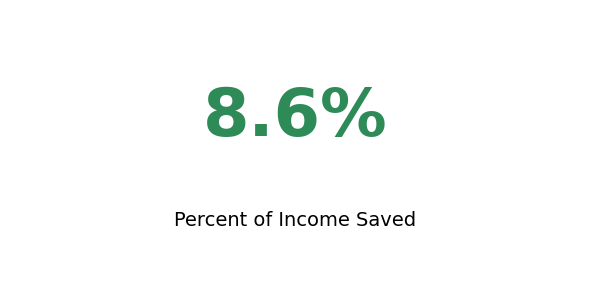

In [293]:
#Make Big number graph to show percent savings

# big number
big_number = 13.74-5.12

fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor('white')
ax.axis('off')  # Hide axes

# Display the number
ax.text(0.5, 0.6, f'{big_number:.1f}%', fontsize=48, fontweight='bold', color = 'seagreen', ha='center', va='center')
ax.text(0.5, 0.2, 'Percent of Income Saved', fontsize=14, ha='center')

plt.tight_layout()
plt.show()


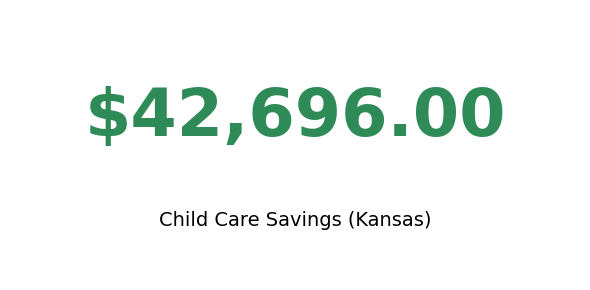

In [351]:
# Big number for cap cut reel 

big_number = 42696

fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor('white')
ax.axis('off')  # Hide axes

# Display the number as dollars
ax.text(0.5, 0.6, f'${big_number:,.2f}', fontsize=48, fontweight='bold', color='seagreen', ha='center', va='center')
ax.text(0.5, 0.2, 'Child Care Savings (Kansas)', fontsize=14, ha='center')

plt.tight_layout()
plt.show()